In [ ]:
import streamlit as st

<h1 style="color: teal; text-align: center;">IPL Match Winner Prediction</h1>
<p style="text-align: center;"><b>By Abraham PonnuRaj | DA &amp; DS | Feb-2025 Batch</b></p>
<hr style="border: 1px dashed #ccc;">
<marquee behavior="scroll" direction="left" scrollamount="6" style="color:orange; font-size:18px;">
Welcome to IPL Data Science Project! Built by Abraham PonnuRaj – DA & DS – Feb 2025
</marquee>


<h3 style='color: yellow'>Objective</h3>

<p>
The aim of this project is to <b>predict the winner of an IPL match</b> based on various features such as the 
teams playing, toss winner, toss decision, and other match-related factors using different 
<b>machine learning models</b>. The best model must be selected after evaluating the performance, and 
<b>hyperparameters must be tuned</b> for further improvements.
</p>
<ul>
  <li>Logistic Regression</li>
  <li>Support Vector Machine (SVM)</li>
  <li>K-Nearest Neighbors (KNN)</li>
  <li>Decision Tree</li>
  <li>Random Forest</li>
  <li>XGBoost</li>
</ul>



<h3>Dataset Description</h3>

<p>
The IPL dataset consists of detailed information about cricket matches played in the Indian Premier League (IPL). 
Each row represents a single match and includes metadata, team details, match outcomes, and other contextual information.
</p>

<table border = 1>
  <tr><th>Column</th><th>Description</th></tr>
  <tr><td><b>id</b></td><td>Unique identifier for each match</td></tr>
  <tr><td><b>Season</b></td><td>The IPL season (year) the match was played</td></tr>
  <tr><td><b>city</b></td><td>City where the match took place</td></tr>
  <tr><td><b>date</b></td><td>Date of the match</td></tr>
  <tr><td><b>team1</b></td><td>The first team (in the match record)</td></tr>
  <tr><td><b>team2</b></td><td>The second team</td></tr>
  <tr><td><b>toss_winner</b></td><td>The team that won the toss</td></tr>
  <tr><td><b>toss_decision</b></td><td>The toss-winning team’s decision (bat or bowl)</td></tr>
  <tr><td><b>result</b></td><td>Match result type (normal, tie, no result)</td></tr>
  <tr><td><b>dl_applied</b></td><td>Whether the Duckworth-Lewis method was applied (1 = Yes, 0 = No)</td></tr>
  <tr><td><b>winner</b></td><td>The team that won the match</td></tr>
  <tr><td><b>win_by_runs</b></td><td>Margin of victory if the team batting first won</td></tr>
  <tr><td><b>win_by_wickets</b></td><td>Margin of victory if the team batting second won</td></tr>
  <tr><td><b>player_of_match</b></td><td>The best-performing player of the match</td></tr>
  <tr><td><b>venue</b></td><td>Stadium where the match was played</td></tr>
  <tr><td><b>umpire1, umpire2, umpire3</b></td><td>Umpires officiating the match</td></tr>
</table>


<h2>Import Libraries</h2>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

<h2>Data Loading and Understanding</h2>

<h3>Load the IPL Dataset</h3>

In [4]:
df_main = pd.read_csv('ipl_matches.csv')
df = df_main.copy()

In [5]:
df.shape

(756, 18)

In [6]:
df.describe()

,id,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,0.025132,13.283069,3.350529
std,3464.478148,0.156630,23.471144,3.387963
min,1.000000,0.000000,0.000000,0.000000
25%,189.750000,0.000000,0.000000,0.000000
50%,378.500000,0.000000,0.000000,4.000000
75%,567.250000,0.000000,19.000000,6.000000
max,11415.000000,1.000000,146.000000,10.000000


In [7]:
df.isnull().sum()

id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [8]:
df.dtypes

id                  int64
Season             object
city               object
date               object
team1              object
team2              object
toss_winner        object
toss_decision      object
result             object
dl_applied          int64
winner             object
win_by_runs         int64
win_by_wickets      int64
player_of_match    object
venue              object
umpire1            object
umpire2            object
umpire3            object
dtype: object

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [10]:
df.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


<h3>Observations</h3>

<ul>
  <li>The dataset contains <b>756</b> and <b>18 columns</b>.</li>
  <li>Key categorical features include: <code>team1</code>, <code>team2</code>, <code>toss_winner</code>, <code>winner</code>, etc.</li>
  <li>Date is stored as <code>object</code>; it may need conversion to <code>datetime</code>.</li>
  <li>Some columns like <code>umpire3</code> have many null values and needs to handle this.</li>
  <li>Columns like <code>win_by_runs</code> and <code>win_by_wickets</code> describe the type of win.</li>
</ul>


In [11]:
df.tail()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin
755,11415,IPL-2019,Hyderabad,12-05-2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Mumbai Indians,1,0,JJ Bumrah,Rajiv Gandhi Intl. Cricket Stadium,Nitin Menon,Ian Gould,Nigel Llong


<h3>Convert Datatypes</h3>

In [12]:
# convert "date" object datatype to date
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [13]:
categorical_cols = ['Season', 'city', 'team1', 'team2', 'toss_winner', 'toss_decision',
                    'result', 'winner', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               756 non-null    int64         
 1   Season           756 non-null    category      
 2   city             749 non-null    category      
 3   date             756 non-null    datetime64[ns]
 4   team1            756 non-null    category      
 5   team2            756 non-null    category      
 6   toss_winner      756 non-null    category      
 7   toss_decision    756 non-null    category      
 8   result           756 non-null    category      
 9   dl_applied       756 non-null    int64         
 10  winner           752 non-null    category      
 11  win_by_runs      756 non-null    int64         
 12  win_by_wickets   756 non-null    int64         
 13  player_of_match  752 non-null    category      
 14  venue            756 non-null    category 

<h3>Data Cleaning</h3>

In [15]:
# Drop umpire3 column, because it has only 119 non-null values 
df.drop(columns=['umpire3'], inplace=True)

In [16]:
# Fill categorical columns null values with mode
cat_fill_cols = ['city', 'player_of_match', 'umpire1', 'umpire2']
for col in cat_fill_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Abu\AppData\Local\Temp\ipykernel_14512\3610782903.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [17]:
df['city'] = df['city'].replace({'Bangalore': 'Bengaluru'})

C:\Users\Abu\AppData\Local\Temp\ipykernel_14512\1960448899.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['city'] = df['city'].replace({'Bangalore': 'Bengaluru'})


In [22]:
#drop the rows where winner has null values, in this dataset there are 4 rows have null in winner column
df.dropna(subset=['winner'], inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 755
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               752 non-null    int64         
 1   Season           752 non-null    category      
 2   city             752 non-null    category      
 3   date             752 non-null    datetime64[ns]
 4   team1            752 non-null    category      
 5   team2            752 non-null    category      
 6   toss_winner      752 non-null    category      
 7   toss_decision    752 non-null    category      
 8   result           752 non-null    category      
 9   dl_applied       752 non-null    int64         
 10  winner           752 non-null    category      
 11  win_by_runs      752 non-null    int64         
 12  win_by_wickets   752 non-null    int64         
 13  player_of_match  752 non-null    category      
 14  venue            752 non-null    category      

In [24]:
df.isnull().sum()

id                 0
Season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

<h3>Cleaning Summary</h3>

<ul>
  <li>Dropped <code>umpire3</code> column due to too many missing values.</li>
  <li>Filled missing categorical values in <code>city</code>, <code>player_of_match</code>, <code>umpire1</code>, <code>umpire2</code> with their mode.</li>
  <li>Dropped 4 rows with missing <code>winner</code> (target column).</li>
</ul>


<h3>Encode Categorical Variables</h3>

In [25]:
df_encoded = df.copy()

In [26]:
# Encode all categorical features (columns)
label_encoders = {}
for col in df_encoded.select_dtypes(include='category').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le 

In [27]:
df_encoded_one_hot = pd.get_dummies(df, drop_first=True)

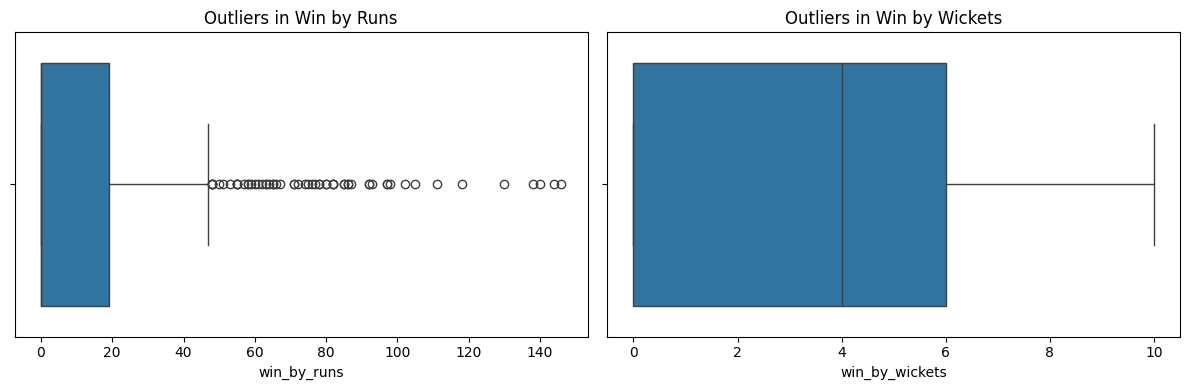

In [28]:
# Visual check of outliers
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_encoded['win_by_runs'])
plt.title("Outliers in Win by Runs")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_encoded['win_by_wickets'])
plt.title("Outliers in Win by Wickets")

plt.tight_layout()
plt.show()

In [30]:
fig1 = px.box(df, y="win_by_runs", title="Boxplot of Win by Runs", points="all")
fig1.show()

In [31]:
fig2 = px.box(df, y="win_by_wickets", title="Boxplot of Win by Wickets", points="all")
fig2.show()

In [32]:
fig = px.box(df, x="Season", y="win_by_runs", color="Season", title="Win by Runs by Season", points="all")
fig.show()

In [33]:
fig = px.box(df, x="Season", y="win_by_wickets", color="Season", title="Win by Wickets by Season", points="all")
fig.show()

In [29]:
df_encoded.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,9,14,2017-04-05,14,13,13,1,0,0,14,35,0,224,28,6,34
1,2,9,26,2017-04-06,8,11,11,1,0,0,11,0,7,199,21,1,49
2,3,9,28,2017-04-07,4,7,7,1,0,0,7,0,10,34,31,38,16
3,4,9,15,2017-04-08,11,5,5,1,0,0,5,0,6,61,13,3,14
4,5,9,2,2017-04-08,13,3,13,0,0,0,13,15,0,99,17,22,14


<h2>Exploratory Data Analysis (EDA)</h2>
<h4>Visualize key patterns and relationships in the data using plots (e.g., bar charts, histograms, pie charts, etc.).</h4>
<h4>Explore correlations between features and the target variable (winner).</h4>
<h4>Create visualizations for team performance, toss outcomes, and other relevant statistics.</h4>
<h4>Document your observations from the visualizations.</h4>

In [30]:
sns.set(style='whitegrid') # Adds a white background with light grey grid lines

<h3>Matches Played by Each Team</h3>

C:\Users\Abu\AppData\Local\Temp\ipykernel_14940\2157143458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_concats.index, y=team_concats.values, palette='viridis')


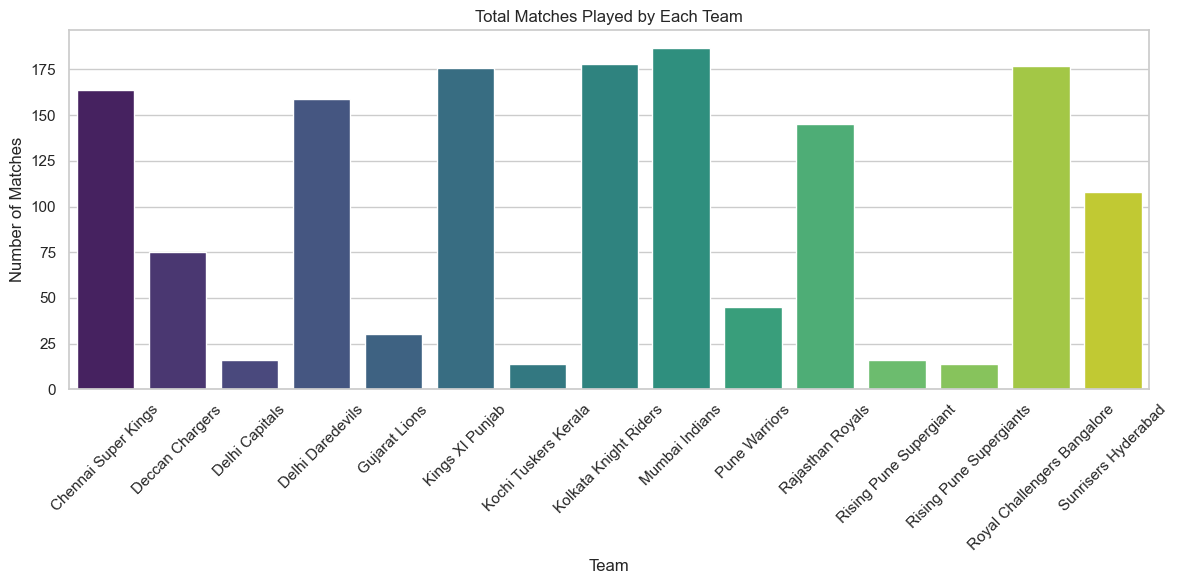

In [31]:
# Concatenate team1 and team2 to get total matches played
team_concats = pd.concat([df['team1'], df['team2']]).value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=team_concats.index, y=team_concats.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Total Matches Played by Each Team')
plt.ylabel('Number of Matches')
plt.xlabel('Team')
plt.tight_layout()
plt.show()


<h3>Number of Wins per Team</h3>

In [32]:
win_counts = df['winner'].value_counts()
win_counts

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Delhi Capitals                  10
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

C:\Users\Abu\AppData\Local\Temp\ipykernel_14940\810558400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.index, y=win_counts.values, palette='coolwarm')


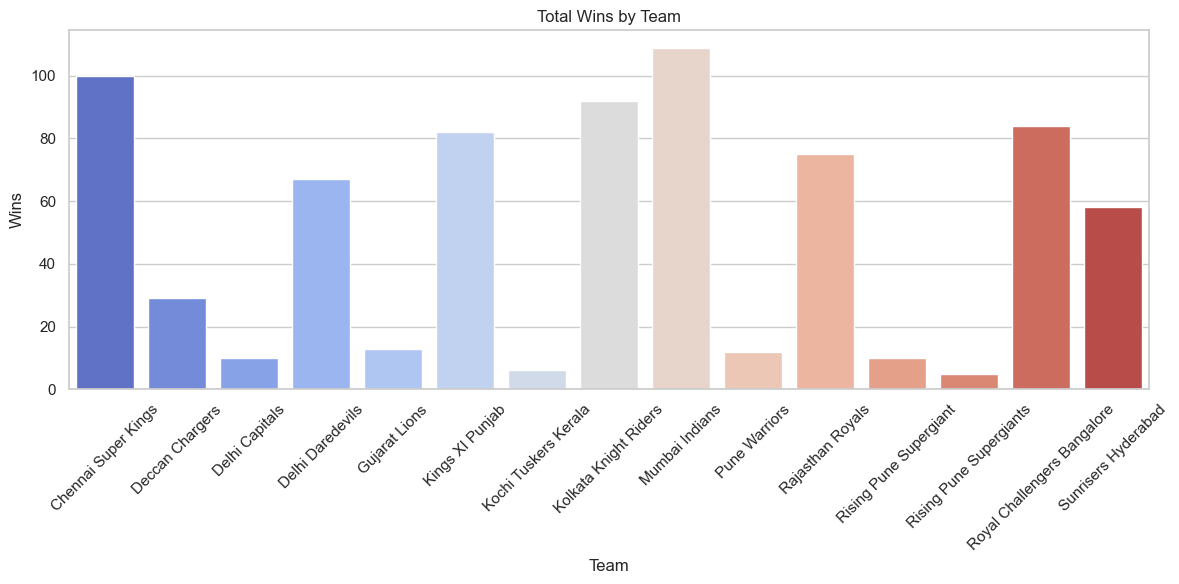

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=win_counts.index, y=win_counts.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Total Wins by Team')
plt.ylabel('Wins')
plt.xlabel('Team')
plt.tight_layout()
plt.show()

<h3>Toss Decision Analysis</h3>

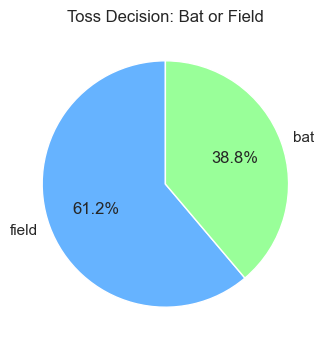

In [34]:
plt.figure(figsize=(6,4))
df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Toss Decision: Bat or Field')
plt.ylabel('')
plt.show()

<h3>Toss Winner vs Match Winner</h3>

In [35]:
toss_win_match_win = (df['toss_winner'] == df['winner']).value_counts()
toss_win_match_win

True     393
False    359
Name: count, dtype: int64

C:\Users\Abu\AppData\Local\Temp\ipykernel_14940\1303834910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_win_match_win.index, y=toss_win_match_win.values, palette='Set2')


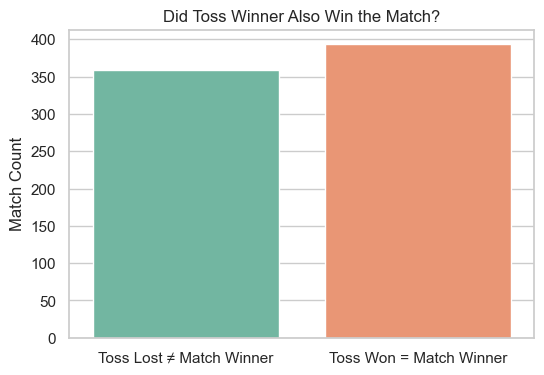

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(x=toss_win_match_win.index, y=toss_win_match_win.values, palette='Set2')
plt.xticks([0,1], ['Toss Lost ≠ Match Winner', 'Toss Won = Match Winner'])
plt.title('Did Toss Winner Also Win the Match?')
plt.ylabel('Match Count')
plt.xlabel('')
plt.show() 

<h3>Distribution of Win Margins</h3>

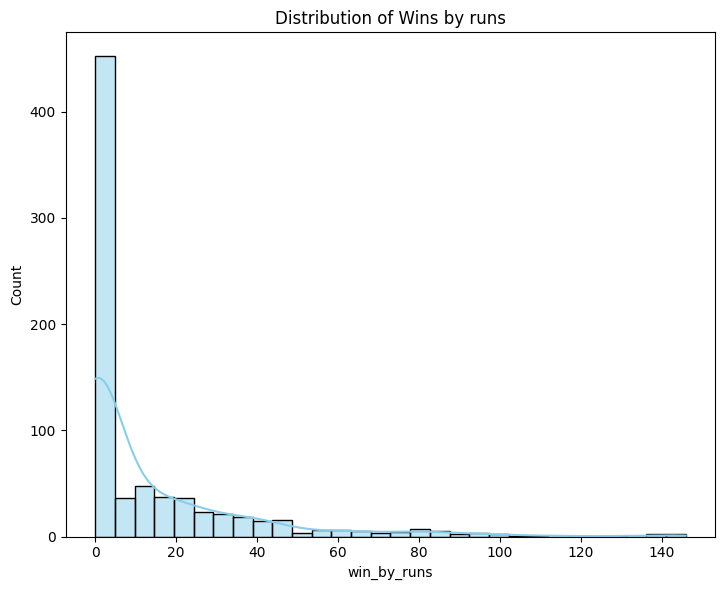

In [43]:
plt.figure(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.histplot(df['win_by_runs'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Wins by runs')
plt.tight_layout()
plt.show()

<h3>Top Players of the Match</h3>

In [38]:
top_players = df['player_of_match'].value_counts().head(10).reset_index()
top_players.columns = ['player', 'awards']
print(top_players)

           player  awards
0        CH Gayle      21
1  AB de Villiers      20
2        MS Dhoni      17
3       DA Warner      17
4       RG Sharma      17
5       YK Pathan      16
6       SR Watson      15
7        SK Raina      14
8       G Gambhir      13
9      MEK Hussey      12


In [39]:
fig = px.bar(
    top_players,
    x='player',
    y='awards',
    color='player',
    title='Top 10 Players of the Match',
    color_discrete_sequence=px.colors.sequential.Plasma
)

fig.update_layout(
    xaxis_title="Player",
    yaxis_title="Awards",
    xaxis_tickangle=-45,
    showlegend=False,
    template='plotly_white'
)

fig.show()

<h3>Data Preprocessing</h3>

<h4>Split the dataset into training and testing sets (e.g., 80% training and 20% testing).</h4>
<h4>Scale/normalize numerical features if required.</h4>
<h4>Prepare feature sets (X) and target labels (y).</h4>

In [40]:
# Prepare Features (X) and Target (y)
# Target = Winner
# Exclude this columns [id, date, player_of_match, umpire1, umpire2, winner (target)] in X
# Features and Targets
X = df.drop(columns=['id', 'date', 'player_of_match', 'umpire1', 'umpire2', 'winner'])
y = df['winner']

<h3>Encode Categorical Features</h3>

In [41]:
# We will use One-Hot Encoding (it is useful for linear and tree-based models):
X_encoded = pd.get_dummies(X, drop_first=True)
#Encode target too (LabelEncoding — It is useful for classification)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

<h3>Split Dataset</h3>

In [42]:
# Using 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

<h3>Normalize Numeric Features</h3>

In [43]:
# Normalized features for models like KNN, SVM, and Logistic Regression.
scaler = StandardScaler()

# Fit on training data and transform both 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# X_train_scaled and X_test_scaled is used for scale-sensitive models.
# X_train, X_test are for tree models like Random Forest/XGBoost.

<h2>Model Training</h2>

<h4>Train multiple machine learning models (Logistic Regression, SVM, KNN, Decision Trees, Random Forest, XGBoost).</h4>
<h4>Evaluate the performance of each model using appropriate metrics like accuracy, precision, recall, and F1-score.</h4>

In [58]:
# Function to Train & Evaluate
results = []
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Print results
    print(f"{model_name} Evaluation:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("-" * 50)

    # Append to results list
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })



<h4>Train Models</h4>

In [ ]:
# Logistic Regression (scaled)
evaluate_model(LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")


Logistic Regression Evaluation:
Accuracy : 0.5099
Precision: 0.4991
Recall   : 0.5099
F1 Score : 0.4931
--------------------------------------------------


In [60]:
# SVM (scaled)
evaluate_model(SVC(), X_train_scaled, X_test_scaled, y_train, y_test, "Support Vector Machine")

Support Vector Machine Evaluation:
Accuracy : 0.4901
Precision: 0.4881
Recall   : 0.4901
F1 Score : 0.4850
--------------------------------------------------


c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [61]:
# KNN (scaled)
evaluate_model(KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbors")


K-Nearest Neighbors Evaluation:
Accuracy : 0.4702
Precision: 0.4844
Recall   : 0.4702
F1 Score : 0.4615
--------------------------------------------------


In [62]:
# Decision Tree (raw data)
evaluate_model(DecisionTreeClassifier(), X_train, X_test, y_train, y_test, "Decision Tree")

Decision Tree Evaluation:
Accuracy : 0.9073
Precision: 0.9117
Recall   : 0.9073
F1 Score : 0.9045
--------------------------------------------------


c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [63]:
# Random Forest (raw data)
evaluate_model(RandomForestClassifier(n_estimators=100), X_train, X_test, y_train, y_test, "Random Forest")


Random Forest Evaluation:
Accuracy : 0.8278
Precision: 0.8194
Recall   : 0.8278
F1 Score : 0.8184
--------------------------------------------------


c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [64]:
# XGBoost (raw data)
evaluate_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), X_train, X_test, y_train, y_test, "XGBoost")

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[19:14:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




XGBoost Evaluation:
Accuracy : 0.9272
Precision: 0.9303
Recall   : 0.9272
F1 Score : 0.9239
--------------------------------------------------


c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



<h3>Model Training & Evaluation Summary</h3>

Six models were trained to predict IPL match winners using pre-match features:

<ul>
  <li><b>Logistic Regression</b> – Suitable for baseline linear performance.</li>
  <li><b>SVM</b> – Good for high-dimensional data, used with scaling.</li>
  <li><b>KNN</b> – Based on distance, sensitive to scaling.</li>
  <li><b>Decision Tree</b> – Rule-based classifier, no scaling needed.</li>
  <li><b>Random Forest</b> – Ensemble of trees, robust and often top-performer.</li>
  <li><b>XGBoost</b> – Advanced boosting, efficient and highly accurate.</li>
</ul>

Each model was evaluated using:
<ul>
  <li>Accuracy</li>
  <li>Precision</li>
  <li>Recall</li>
  <li>F1-Score</li>
</ul>


In [65]:
results_df = pd.DataFrame(results)
print("Model Comparison Table:")
display(results_df.sort_values(by='Accuracy', ascending=False))


Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.927152,0.930294,0.927152,0.923882
3,Decision Tree,0.907285,0.911702,0.907285,0.904504
4,Random Forest,0.827815,0.819355,0.827815,0.818443
0,Logistic Regression,0.509934,0.499121,0.509934,0.493146
1,Support Vector Machine,0.490066,0.488069,0.490066,0.484951
2,K-Nearest Neighbors,0.470199,0.484365,0.470199,0.461524


In [66]:
# Plot accuracy comparison
fig = px.bar(
    results_df.sort_values(by='Accuracy', ascending=False),
    x='Model',
    y='Accuracy',
    color='Model',
    title='Accuracy Comparison of ML Models',
    text='Accuracy',
    color_discrete_sequence=px.colors.sequential.Plasma
)

fig.update_layout(
    xaxis_title='Machine Learning Model',
    yaxis_title='Accuracy Score',
    xaxis_tickangle=-45,
    showlegend=False,
    template='plotly_white'
)

fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')  # Show as %
fig.show()

<h3>Model Evaluation</h3>

<h4>Compare the performance of each model using metrics such as accuracy, confusion matrix, precision, recall, and F1 score.</h4>
<h4>Select the best-performing model based on evaluation results.</h4>


In [69]:
# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

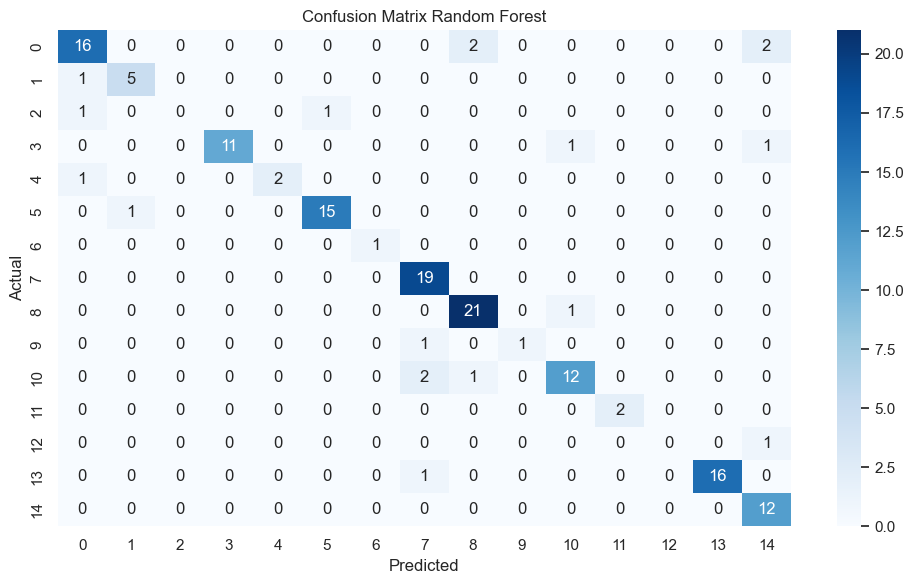

Classification Report-Random Forest
                             precision    recall  f1-score   support

        Chennai Super Kings       0.84      0.80      0.82        20
            Deccan Chargers       0.83      0.83      0.83         6
             Delhi Capitals       0.00      0.00      0.00         2
           Delhi Daredevils       1.00      0.85      0.92        13
              Gujarat Lions       1.00      0.67      0.80         3
            Kings XI Punjab       0.94      0.94      0.94        16
       Kochi Tuskers Kerala       1.00      1.00      1.00         1
      Kolkata Knight Riders       0.83      1.00      0.90        19
             Mumbai Indians       0.88      0.95      0.91        22
              Pune Warriors       1.00      0.50      0.67         2
           Rajasthan Royals       0.86      0.80      0.83        15
     Rising Pune Supergiant       1.00      1.00      1.00         2
    Rising Pune Supergiants       0.00      0.00      0.00        

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
# Evaluate Each Model (Random Forest)
# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Confusion Matrix
# Confusion Matrix shows how many matches were correctly/incorrectly predicted for each team.
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# Classification Report
# Precision: How many predicted wins were correct.
# Recall: How many actual wins were correctly predicted.
# F1-score: Balance of both precision and recall.
print("Classification Report-Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:10:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




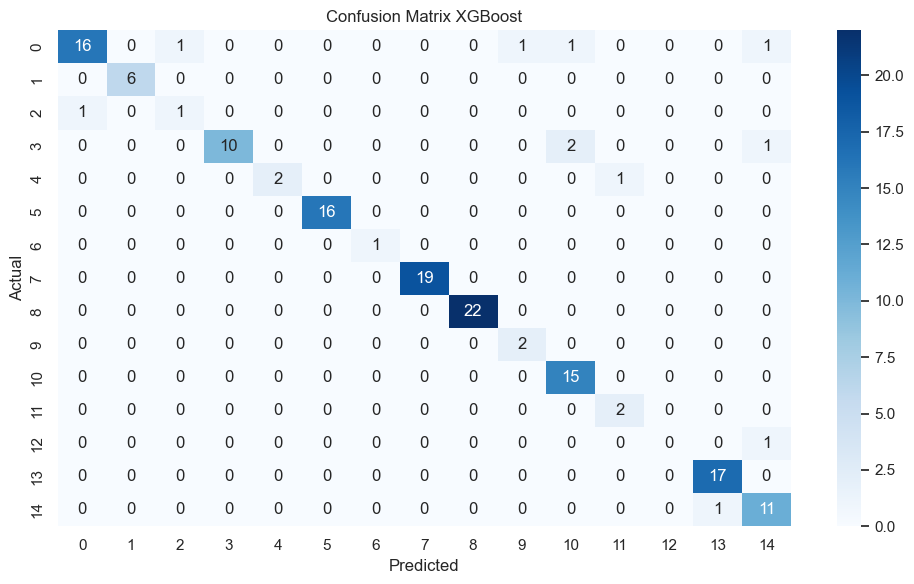

Classification Report-XGBoost
                             precision    recall  f1-score   support

        Chennai Super Kings       0.94      0.80      0.86        20
            Deccan Chargers       1.00      1.00      1.00         6
             Delhi Capitals       0.50      0.50      0.50         2
           Delhi Daredevils       1.00      0.77      0.87        13
              Gujarat Lions       1.00      0.67      0.80         3
            Kings XI Punjab       1.00      1.00      1.00        16
       Kochi Tuskers Kerala       1.00      1.00      1.00         1
      Kolkata Knight Riders       1.00      1.00      1.00        19
             Mumbai Indians       1.00      1.00      1.00        22
              Pune Warriors       0.67      1.00      0.80         2
           Rajasthan Royals       0.83      1.00      0.91        15
     Rising Pune Supergiant       0.67      1.00      0.80         2
    Rising Pune Supergiants       0.00      0.00      0.00         1
Roy

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [71]:
# XGBoost
# Train model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")

# Classification Report
print("Classification Report-XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

<h4>Import Required Metrics</h4>

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

<h4>Create a List of Models & Predictions</h4>

In [74]:
models_summary = []

# Random Forest metrics
models_summary.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_rf, average='weighted'),
    'Macro F1': f1_score(y_test, y_pred_rf, average='macro')
})

# XGBoost metrics
models_summary.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_xgb, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_xgb, average='weighted'),
    'Macro F1': f1_score(y_test, y_pred_xgb, average='macro')
})

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [75]:
results_dynamic_df = pd.DataFrame(models_summary)
results_dynamic_df.set_index('Model', inplace=True)
display(results_dynamic_df.sort_values(by='Accuracy', ascending=False))

,Accuracy,Precision,Recall,F1 Score,Macro F1
Model,,,,,
XGBoost,0.927152,0.930294,0.927152,0.923882,0.824074
Random Forest,0.880795,0.871821,0.880795,0.871007,0.763127


In [76]:
# Accuracy Comparison
fig = px.bar(
    results_dynamic_df.reset_index(),
    x='Model',
    y='Accuracy',
    color='Model',
    title='Accuracy Comparison of ML Models',
    text='Accuracy',
    color_discrete_sequence=px.colors.sequential.Plasma
)

fig.update_layout(
    xaxis_title='Model',
    yaxis_title='Accuracy',
    showlegend=False,
    xaxis_tickangle=-45,
    template='plotly_white'
)

fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.show()

In [77]:
# Reset index to get 'Model' as column
long_df = results_dynamic_df.reset_index().melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    var_name='Metric',
    value_name='Score'
)

In [ ]:
# Plot Grouped Bar Chart Using Plotly
fig = px.bar(
    long_df,
    x='Model',
    y='Score',
    color='Metric',
    barmode='group',
    title='Model Performance Comparison Accuracy, Precision, Recall, F1 Score',
    text='Score',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    xaxis_title='Model',
    yaxis_title='Score',
    yaxis=dict(range=[0, 1]),
    template='plotly_white',
    legend_title='Metric'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

### Model Evaluation – Observations

1. **XGBoost outperformed all other models** in terms of:
   - Accuracy (93%)
   - Precision, Recall, and F1-score (all above 92%)
   - Better handling of minority class predictions (higher macro F1-score)

2. **Random Forest** also performed well (88% accuracy), but had slightly lower F1-scores for some teams with fewer matches.

3. Both models showed limitations when predicting rare teams (e.g., Rising Pune Supergiants, Delhi Capitals), where very few samples existed.

4. XGBoost demonstrated **strong consistency across all team classes**, making it the best candidate for final deployment and future predictions.

**Conclusion**: Based on evaluation metrics and confusion matrix analysis, **XGBoost is the best-performing model** for IPL match winner prediction.


<h2>Hyperparameter Tuning:</h2>

<h4>GridSearchCV</h4>

In [80]:
xgb_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning:

The least populated class in y has only 4 members, which is less than n_splits=5.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:36:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [82]:
best_xgb_params = xgb_grid.best_params_
print("Best Hyperparameters for XGBoost:", best_xgb_params)

Best Hyperparameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}


In [83]:
# Retrain Final XGBoost with Best Parameters
final_xgb = XGBClassifier(
    **best_xgb_params,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

final_xgb.fit(X_train, y_train)

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning:

[20:37:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


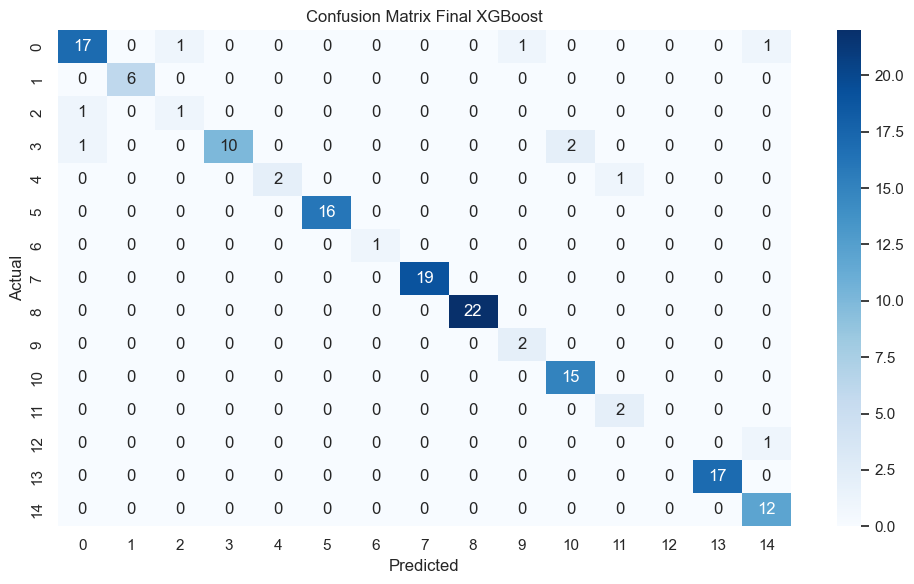

Final Classification Report – Tuned XGBoost
                             precision    recall  f1-score   support

        Chennai Super Kings       0.89      0.85      0.87        20
            Deccan Chargers       1.00      1.00      1.00         6
             Delhi Capitals       0.50      0.50      0.50         2
           Delhi Daredevils       1.00      0.77      0.87        13
              Gujarat Lions       1.00      0.67      0.80         3
            Kings XI Punjab       1.00      1.00      1.00        16
       Kochi Tuskers Kerala       1.00      1.00      1.00         1
      Kolkata Knight Riders       1.00      1.00      1.00        19
             Mumbai Indians       1.00      1.00      1.00        22
              Pune Warriors       0.67      1.00      0.80         2
           Rajasthan Royals       0.88      1.00      0.94        15
     Rising Pune Supergiant       0.67      1.00      0.80         2
    Rising Pune Supergiants       0.00      0.00      0.00

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
y_pred_final = final_xgb.predict(X_test)

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred_final, "Final XGBoost")

# Classification Report
print("Final Classification Report - Tuned XGBoost")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

<h2>Final Model Predictions</h2>

In [85]:
# y_test: actual labels
# y_pred_final: predictions from tuned XGBoost
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, average='weighted')
final_recall = recall_score(y_test, y_pred_final, average='weighted')
final_f1_weighted = f1_score(y_test, y_pred_final, average='weighted')
final_f1_macro = f1_score(y_test, y_pred_final, average='macro')

c:\Users\Abu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [86]:
final_eval_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score', 'Macro F1-Score'],
    'Score': [final_accuracy, final_precision, final_recall, final_f1_weighted, final_f1_macro]
})

final_eval_df['Score'] = final_eval_df['Score'].round(4)  # round for presentation
display(final_eval_df)

,Metric,Score
0,Accuracy,0.9404
1,Weighted Precision,0.9409
2,Weighted Recall,0.9404
3,Weighted F1-Score,0.9370
4,Macro F1-Score,0.8335


In [92]:
import joblib

# Save the final tuned XGBoost model
joblib.dump(final_xgb, 'xgboost_ipl_final_model.pkl')


['xgboost_ipl_final_model.pkl']

In [88]:
df.to_csv("ipl_df.csv", index=False)

<h3>Get Exact Installed Versions</h3>

In [ ]:
# pip show streamlit pandas joblib scikit-learn xgboost matplotlib seaborn plotly

In [96]:
import joblib

# Load the model
model = joblib.load("xgboost_ipl_final_model.pkl")


joblib.dump(list(X_train.columns), "model_features.pkl")

# Extract feature names from the booster
booster = model.get_booster()
feature_names = booster.feature_names

# Print the feature names
print("Model was trained on the following features:")
for name in feature_names:
    print(name)


Model was trained on the following features:
dl_applied
win_by_runs
win_by_wickets
Season_IPL-2009
Season_IPL-2010
Season_IPL-2011
Season_IPL-2012
Season_IPL-2013
Season_IPL-2014
Season_IPL-2015
Season_IPL-2016
Season_IPL-2017
Season_IPL-2018
Season_IPL-2019
city_Ahmedabad
city_Bangalore
city_Bengaluru
city_Bloemfontein
city_Cape Town
city_Centurion
city_Chandigarh
city_Chennai
city_Cuttack
city_Delhi
city_Dharamsala
city_Durban
city_East London
city_Hyderabad
city_Indore
city_Jaipur
city_Johannesburg
city_Kanpur
city_Kimberley
city_Kochi
city_Kolkata
city_Mohali
city_Mumbai
city_Nagpur
city_Port Elizabeth
city_Pune
city_Raipur
city_Rajkot
city_Ranchi
city_Sharjah
city_Visakhapatnam
team1_Deccan Chargers
team1_Delhi Capitals
team1_Delhi Daredevils
team1_Gujarat Lions
team1_Kings XI Punjab
team1_Kochi Tuskers Kerala
team1_Kolkata Knight Riders
team1_Mumbai Indians
team1_Pune Warriors
team1_Rajasthan Royals
team1_Rising Pune Supergiant
team1_Rising Pune Supergiants
team1_Royal Challenger

In [18]:
season_count = df['Season'].value_counts().sort_index().reset_index()
season_count.columns = ['Season', 'Matches']

In [19]:
fig_bar = px.bar(season_count, x='Season', y='Matches',
                 title="Number of Matches per IPL Season",
                 labels={'Matches': 'Number of Matches'},
                 color='Matches',
                 text='Matches')
fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(xaxis_title='Season', yaxis_title='Matches')
fig_bar.show()

In [20]:
fig_line = px.line(season_count, x='Season', y='Matches',
                   title="Trend of Matches per Season",
                   markers=True,
                   labels={'Matches': 'Number of Matches'})
fig_line.update_layout(xaxis_title='Season', yaxis_title='Matches')
fig_line.show()

In [21]:
win_count = df['winner'].value_counts().reset_index()
win_count.columns = ['Team', 'Wins']

In [23]:
fig_bar = px.bar(win_count, x='Team', y='Wins',
                 title="IPL Team Win Distribution (Bar Chart)",
                 text='Wins', color='Wins')
fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(xaxis_title='Team', yaxis_title='Total Wins')
fig_bar.show()

In [24]:
city_count = df['city'].value_counts().reset_index()
city_count.columns = ['City', 'Matches']

In [25]:
fig_city_bar = px.bar(city_count, x='City', y='Matches',
                      title="Frequency of Matches by City",
                      text='Matches', color='Matches',
                      labels={'Matches': 'Number of Matches'})
fig_city_bar.update_traces(textposition='outside')
fig_city_bar.update_layout(xaxis_tickangle=-45)
fig_city_bar.show()

In [26]:
umpires = pd.concat([df['umpire1'], df['umpire2']])
umpire_counts = umpires.value_counts().reset_index()
umpire_counts.columns = ['Umpire', 'Matches']

In [27]:
fig_umpire_bar = px.bar(umpire_counts.head(15), x='Umpire', y='Matches',
                        title="Top 15 Umpires by Match Count",
                        text='Matches', color='Matches',
                        labels={'Matches': 'Number of Matches'})
fig_umpire_bar.update_traces(textposition='outside')
fig_umpire_bar.update_layout(xaxis_tickangle=-45)
fig_umpire_bar.show()

In [34]:
no_wicket_loss_df = df[df['win_by_wickets']==10]

In [35]:
team_clean_sweeps = no_wicket_loss_df['winner'].value_counts().reset_index()
team_clean_sweeps.columns = ['Team', '10-Wicket Wins']

In [36]:
fig = px.bar(team_clean_sweeps, x='Team', y='10-Wicket Wins',
             title='Teams That Won Without Losing Any Wicket (10-Wicket Wins)',
             color='10-Wicket Wins',
             text='10-Wicket Wins')

In [37]:
fig.update_layout(xaxis_title="Team",
                  yaxis_title="Number of 10-Wicket Wins",
                  template='plotly_white')
fig.show()

In [38]:
dl_count = df['dl_applied'].value_counts()
print(dl_count)

dl_applied
0    737
1     19
Name: count, dtype: int64


In [39]:
dl_percentage = (df['dl_applied'].sum() / len(df)) * 100
print(f"D/L method applied in {dl_percentage:.2f}% of IPL matches")

D/L method applied in 2.51% of IPL matches


In [40]:
dl_data = df['dl_applied'].value_counts().reset_index()
dl_data.columns = ['DL Applied', 'Match Count']
dl_data['DL Applied'] = dl_data['DL Applied'].map({0: 'No', 1: 'Yes'})

fig = px.pie(dl_data, values='Match Count', names='DL Applied',
             title='Matches Affected by Duckworth-Lewis Method',
             color_discrete_sequence=['#00cc96', '#EF553B'])
fig.show()

In [42]:
result_counts = df['result'].value_counts().reset_index()
result_counts.columns = ['Result Type', 'Count']

fig = px.bar(result_counts,
             x='Result Type',
             y='Count',
             color='Result Type',
             text='Count',
             color_discrete_sequence=px.colors.qualitative.Set2, 
             title='Distribution of IPL Match Results')

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title='Result Type', yaxis_title='Number of Matches')
fig.show()